## Monte Carlo Portfolio Calculator

#### Manan Verma
#### 24 May 2026

In [63]:
import numpy as np
import math, random
import matplotlib.pyplot as plt

10,000 portfolio paths will be simulated over 30 year lifetimes. For each year, there is a random annual return: between -5% and 5%, where every value has equal probability.

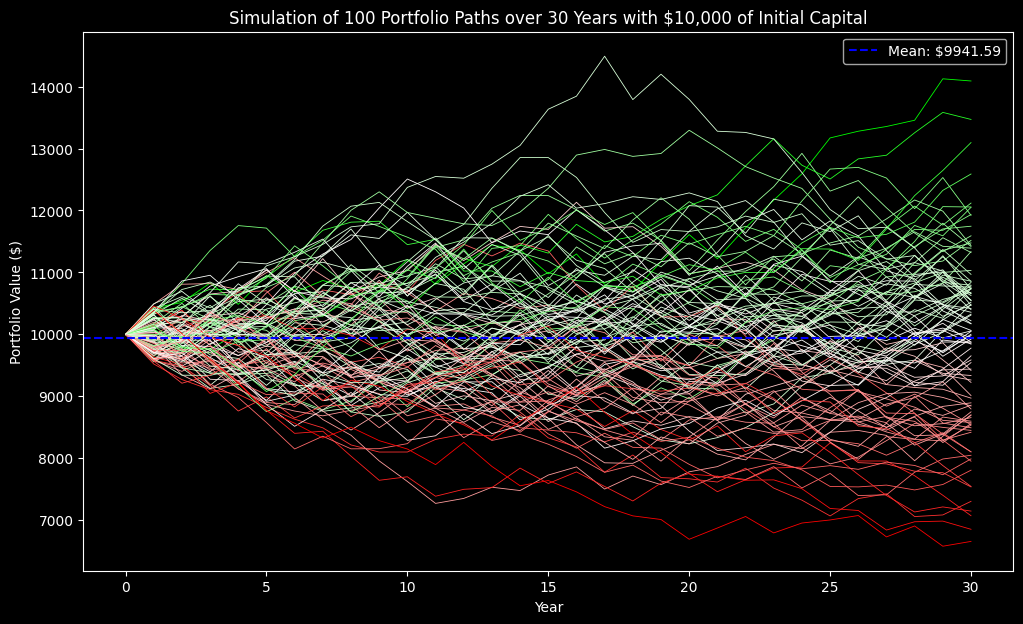

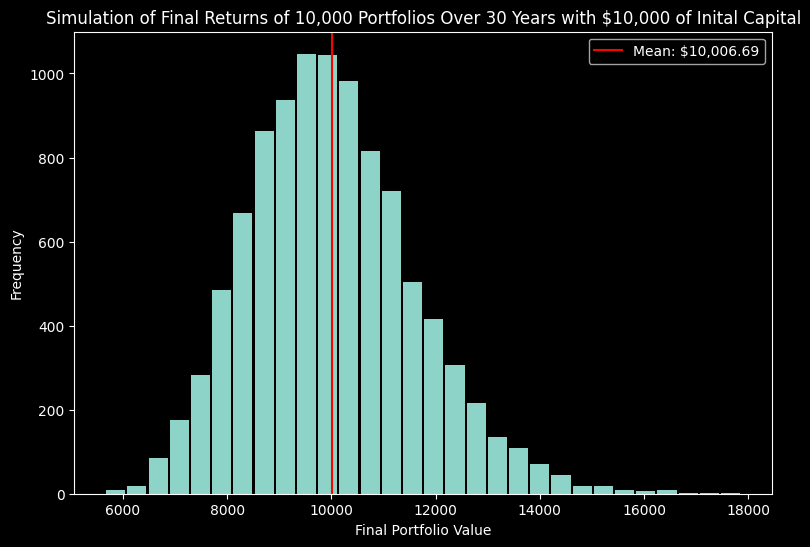

In [64]:
#Simulate the portfolio paths where annual returns follow a uniform distribution

def simulate_path_uniform(init_capital):
    """Simulate the path of a single portfolio over 30 years, given the initial capital.
       Takes as input the initial capital of the portfolio, outputs a list of annual, compounded returns."""
    
    compounded_returns = np.zeros(31)
    compounded_returns[0] = init_capital
    for i in range(1, 31):
        annual_return = random.uniform(-5.0, 5.0) / 100
        compounded_returns[i] = compounded_returns[i - 1] * (1 + annual_return)
    
    return compounded_returns

def find_color(max_profit, min_profit, path):
    """Calculate the RGB color of the specified equity path.
       Takes in as input the max and min PnL over all equity curves and the path in question,
       outputs the RGB value of the given path"""
    pnl = path[-1] - path[0]

    if pnl >= 0:
        ratio = pnl / max_profit
        red, green = 1 - ratio, 1.0
    else:
        ratio = pnl / min_profit
        red, green = 1.0, 1 - ratio

    blue = 1 - ratio
    return (red, green, blue)

#Simulate 100 equity paths and visualize them, each with $10,000 of initial capital
paths_100 = np.array([simulate_path_uniform(10000) for i in range(100)])
plt.style.use('dark_background')
plt.figure(figsize = (12, 7))
pnls = paths_100[:, -1] - paths_100[:, 0]
max_profit = pnls.max()
min_profit = pnls.min()
for path in paths_100:
    plt.plot(path, color = find_color(max_profit, min_profit, path), linewidth = 0.6)
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.axhline(y = np.mean(paths_100[:, -1]), color = 'blue', linestyle = '--', label = f"Mean: ${np.mean(paths_100[:, -1]):.2f}")
plt.title('Simulation of 100 Portfolio Paths over 30 Years with $10,000 of Initial Capital')
plt.legend()

plt.show()

#Simulate 10,000 portfolio paths and visualize the distribution of final values
paths_10000 = np.array([simulate_path_uniform(10000) for i in range(10000)])
plt.figure(figsize = (9, 6))
final_values = np.array(paths_10000[: , -1])
plt.hist(final_values, bins = 30, rwidth = 0.9)
plt.xlabel('Final Portfolio Value')
plt.ylabel('Frequency')
plt.title('Simulation of Final Returns of 10,000 Portfolios Over 30 Years with $10,000 of Inital Capital')
plt.axvline(x = np.mean(final_values), color = 'red', label = f'Mean: ${np.mean(final_values):,.2f}')
plt.legend()

plt.show()

Now, 10,000 portfolio paths will be simulated over 30 year lifetimes. For each year, the annual returns are normally distributed with a mean of 10% and a standard deviation of 19% (the approximate returns of the S&P 500).

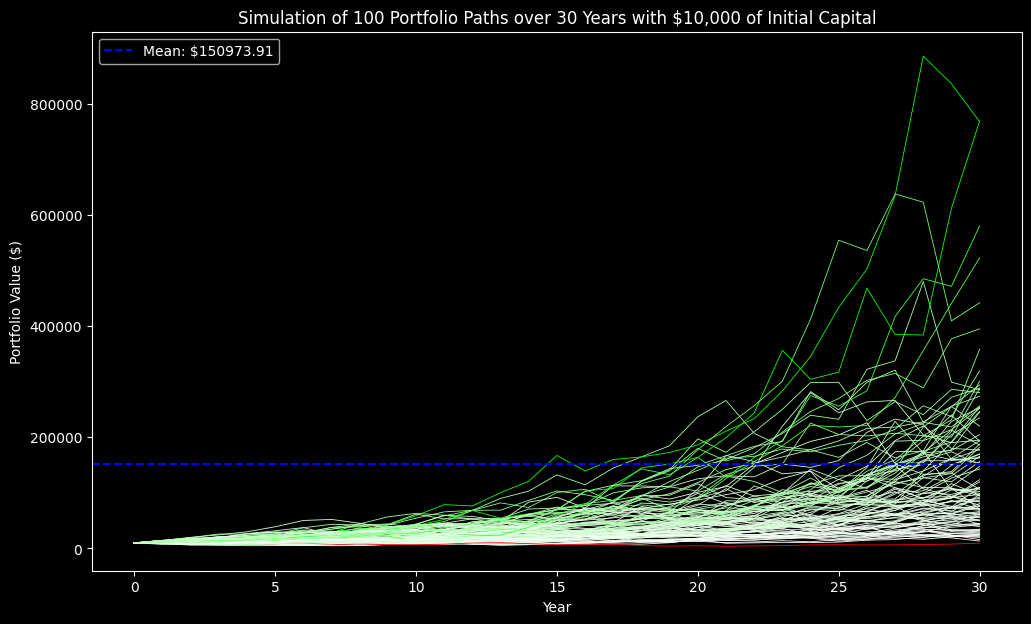

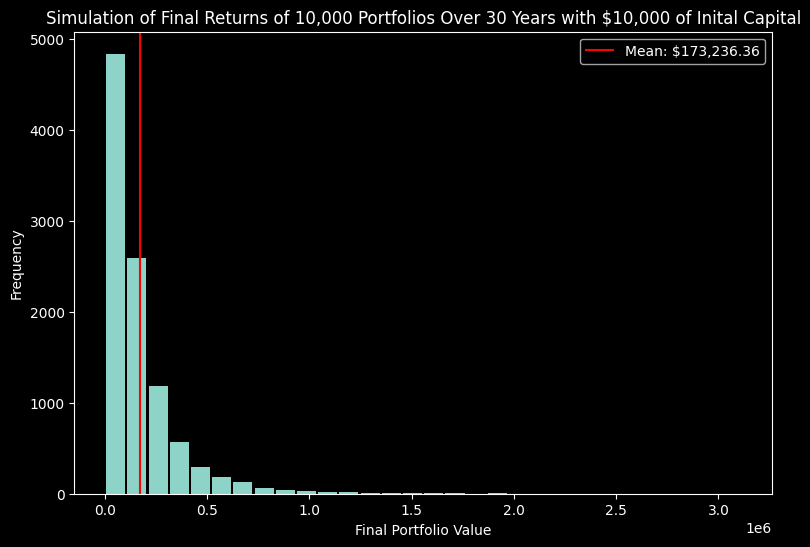

In [65]:
#Simulate the portfolio paths where annual returns follow a normal distribution

def simulate_path_normal(init_capital):
    """Simulate the path of a single portfolio over 30 years, given the initial capital.
       Takes as input the initial capital of the portfolio, outputs a list of annual, compounded returns."""
    
    compounded_returns = np.zeros(31)
    compounded_returns[0] = init_capital
    for i in range(1, 31):
        annual_return = random.gauss(10, 19) / 100
        compounded_returns[i] = compounded_returns[i - 1] * (1 + annual_return)
    
    return compounded_returns

#Simulate 100 equity paths and visualize them, each with $10,000 of initial capital
paths_100 = np.array([simulate_path_normal(10000) for i in range(100)])
plt.style.use('dark_background')
plt.figure(figsize = (12, 7))
pnls = paths_100[:, -1] - paths_100[:, 0]
max_profit = pnls.max()
min_profit = pnls.min()
for path in paths_100:
    plt.plot(path, color = find_color(max_profit, min_profit, path), linewidth = 0.6)
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.axhline(y = np.mean(paths_100[:, -1]), color = 'blue', linestyle = '--', label = f"Mean: ${np.mean(paths_100[:, -1]):.2f}")
plt.title('Simulation of 100 Portfolio Paths over 30 Years with $10,000 of Initial Capital')
plt.legend()

plt.show()

#Simulate 10,000 portfolio paths and visualize the distribution of final values
paths_10000 = np.array([simulate_path_normal(10000) for i in range(10000)])
plt.figure(figsize = (9, 6))
final_values = np.array(paths_10000[: , -1])
plt.hist(final_values, bins = 30, rwidth = 0.9)
plt.xlabel('Final Portfolio Value')
plt.ylabel('Frequency')
plt.title('Simulation of Final Returns of 10,000 Portfolios Over 30 Years with $10,000 of Inital Capital')
plt.axvline(x = np.mean(final_values), color = 'red', label = f'Mean: ${np.mean(final_values):,.2f}')
plt.legend()

plt.show()